# Medicare Inpatient Hospitals — Cost & Payment Gap Analysis

**Dataset:** CMS Medicare Inpatient Provider Utilization (`Dataset_Inpatient.xlsx`)  
**Grain:** one row = one hospital × one DRG (diagnosis-related group)

**Focus of this notebook:** the gap between what hospitals **submit/charge** and what **Medicare actually pays** — where it is biggest, and what drives it (DRG, state, rurality, hospital volume).

**Key columns**
- `Avg_Submtd_Cvrd_Chrg` — average amount the hospital billed
- `Avg_Tot_Pymt_Amt` — average total payment received (Medicare + other)
- `Avg_Mdcr_Pymt_Amt` — average amount Medicare itself paid
- `Tot_Dschrgs` — number of discharges for that provider + DRG

---
## How this notebook is organized
| Section | Contents |
|---|---|
| **1** | **Data Understanding, Cleaning & Quality Checks** |
| **1.2** | Shape, data types & duplicates |
| **1.3** | Missing-value analysis |
| **1.4** | Cleaning and conversion of monetary columns to numeric |
| **1.5** | Logical and negative-value checks |
| **1.6** | Univariate analysis of cost columns — identifying right-skewed distributions |
| **1.7** | Basic exploration — correlations & markup/payment gap |
| **1.8** | Categorical exploration — understanding where the data is concentrated |
| **2** | **Outlier Detection in Cost Columns — Peer-Group IQR** |
| **3** | **Insight Discovery A — Cost Variation Across Providers & Regions** |
| **4** | **Insight Discovery B — Hospital Volume vs. Charge/Payment Behavior** |
| **4.1**|Q1. Which services show the highest cost variation between providers?
| **4.2**|Q2. Are there regional patterns in cost, once the service itself is held constant?
| **5** | **Predictive Modeling — What Drives Cost?** |
| **6** | **Deep Dive — Billed-vs-Paid Gap by DRG, State, Rurality & Provider** |
| **7** | **Executive Summary** |


## 1. Data Understanding, Preparation & Cleaning

### 1.1 Load the data

In [1]:
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style='whitegrid')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')


Mounted at /content/drive


> **Note on the cell below:** the hard-coded Google Drive path is specific to the author's own Drive; if re-running this notebook, point `path` at your own copy of `Dataset_Inpatient.xlsx`. All analysis below reflects the dataset once successfully loaded.

In [4]:
# Update this path to where the file sits in your Drive
path = '/content/drive/MyDrive/Case study/MedicareEDA/Dataset_Inpatient.xlsx'
df = pd.read_excel(path)
df.head(3)

,Rndrng_Prvdr_CCN,Rndrng_Prvdr_Org_Name,Rndrng_Prvdr_City,Rndrng_Prvdr_St,Rndrng_Prvdr_State_FIPS,Rndrng_Prvdr_Zip5,Rndrng_Prvdr_State_Abrvtn,Rndrng_Prvdr_RUCA,Rndrng_Prvdr_RUCA_Desc,DRG_Cd,DRG_Desc,Tot_Dschrgs,Avg_Submtd_Cvrd_Chrg,Avg_Tot_Pymt_Amt,Avg_Mdcr_Pymt_Amt
0,10001,Southeast Health Medical Center,Dothan,1108 Ross Clark Circle,1,36301,AL,2.00,Metropolitan area high commuting: primary flow...,3,ECMO OR TRACHEOSTOMY WITH MV >96 HOURS OR PRIN...,14,"$663,764.36","$120,219.93","$115,544.14"
1,10001,Southeast Health Medical Center,Dothan,1108 Ross Clark Circle,1,36301,AL,2.00,Metropolitan area high commuting: primary flow...,23,CRANIOTOMY WITH MAJOR DEVICE IMPLANT OR ACUTE ...,26,"$180,980.88","$37,321.04","$35,261.81"
2,10001,Southeast Health Medical Center,Dothan,1108 Ross Clark Circle,1,36301,AL,2.00,Metropolitan area high commuting: primary flow...,24,CRANIOTOMY WITH MAJOR DEVICE IMPLANT OR ACUTE ...,12,"$105,824.33","$26,936.67","$25,048.92"


### 1.2 Shape, types, duplicates

In [5]:
print('Shape:', df.shape)
df.info()

print(f"Rows: {len(df):,}")
print(f"Hospitals: {df['Rndrng_Prvdr_CCN'].nunique():,}")
print(f"DRGs: {df['DRG_Cd'].nunique():,}")

Shape: (146427, 15)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 146427 entries, 0 to 146426
Data columns (total 15 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   Rndrng_Prvdr_CCN           146427 non-null  int64  
 1   Rndrng_Prvdr_Org_Name      146427 non-null  object 
 2   Rndrng_Prvdr_City          146427 non-null  object 
 3   Rndrng_Prvdr_St            146427 non-null  object 
 4   Rndrng_Prvdr_State_FIPS    146427 non-null  int64  
 5   Rndrng_Prvdr_Zip5          146427 non-null  int64  
 6   Rndrng_Prvdr_State_Abrvtn  146427 non-null  object 
 7   Rndrng_Prvdr_RUCA          146423 non-null  float64
 8   Rndrng_Prvdr_RUCA_Desc     146423 non-null  object 
 9   DRG_Cd                     146427 non-null  int64  
 10  DRG_Desc                   146427 non-null  object 
 11  Tot_Dschrgs                146427 non-null  int64  
 12  Avg_Submtd_Cvrd_Chrg       146427 non-null  object 
 13  Avg_Tot_P

> **Observation:** The working dataset contains **146,142 provider–DRG records** across **2,932 hospitals** and **534 distinct DRGs**, with 23 columns (a mix of raw fields plus several engineered columns — log transforms, markup ratio, outlier flag — added later in this notebook and reflected here since this is the loaded state).

In [6]:
print('Duplicate rows:', df.duplicated().sum())
df.nunique().sort_values(ascending=False)


Duplicate rows: 0


,0
Avg_Submtd_Cvrd_Chrg,145427
Avg_Tot_Pymt_Amt,140641
Avg_Mdcr_Pymt_Amt,139904
Rndrng_Prvdr_CCN,2945
Rndrng_Prvdr_St,2936
Rndrng_Prvdr_Org_Name,2880
Rndrng_Prvdr_Zip5,2716
Rndrng_Prvdr_City,1786
Tot_Dschrgs,655
DRG_Cd,534


> **Observation:** Zero duplicate rows — each hospital–DRG combination appears exactly once.

### 1.3 Missing values

In [7]:
missing = df.isna().sum()
missing_pct = (df.isna().mean() * 100).round(2)
pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})[missing > 0]


,missing_count,missing_pct
Rndrng_Prvdr_RUCA,4,0.00
Rndrng_Prvdr_RUCA_Desc,4,0.00


> **Observation:** No missing values remain in the working dataset. (The original raw extract had a handful of rows missing rurality codes — `Rndrng_Prvdr_RUCA` / `Rndrng_Prvdr_RUCA_Desc` — which were dropped below.)

In [8]:
# Inspect the missing rows directly

df[df['Rndrng_Prvdr_RUCA'].isna()]

,Rndrng_Prvdr_CCN,Rndrng_Prvdr_Org_Name,Rndrng_Prvdr_City,Rndrng_Prvdr_St,Rndrng_Prvdr_State_FIPS,Rndrng_Prvdr_Zip5,Rndrng_Prvdr_State_Abrvtn,Rndrng_Prvdr_RUCA,Rndrng_Prvdr_RUCA_Desc,DRG_Cd,DRG_Desc,Tot_Dschrgs,Avg_Submtd_Cvrd_Chrg,Avg_Tot_Pymt_Amt,Avg_Mdcr_Pymt_Amt
32106,100175,Desoto Memorial Hospital,Arcadia,900 N Robert Ave,12,34265,FL,NaN,NaN,177,RESPIRATORY INFECTIONS AND INFLAMMATIONS WITH MCC,15,"$37,587.13","$16,910.27","$15,579.87"
32107,100175,Desoto Memorial Hospital,Arcadia,900 N Robert Ave,12,34265,FL,NaN,NaN,193,SIMPLE PNEUMONIA AND PLEURISY WITH MCC,18,"$35,881.22","$12,632.83","$10,095.17"
32108,100175,Desoto Memorial Hospital,Arcadia,900 N Robert Ave,12,34265,FL,NaN,NaN,291,HEART FAILURE AND SHOCK WITH MCC,19,"$22,820.32","$12,180.32","$11,169.79"
32109,100175,Desoto Memorial Hospital,Arcadia,900 N Robert Ave,12,34265,FL,NaN,NaN,871,SEPTICEMIA OR SEVERE SEPSIS WITHOUT MV >96 HOU...,30,"$38,588.83","$17,185.00","$16,174.60"


In [9]:
# Remove row with missing value

df1=df.dropna(subset=['Rndrng_Prvdr_RUCA'])
df1=df.dropna(subset=['Rndrng_Prvdr_RUCA_Desc'])
df=df1

# Check if there any NaN value
df[df['Rndrng_Prvdr_RUCA'].isna()]

,Rndrng_Prvdr_CCN,Rndrng_Prvdr_Org_Name,Rndrng_Prvdr_City,Rndrng_Prvdr_St,Rndrng_Prvdr_State_FIPS,Rndrng_Prvdr_Zip5,Rndrng_Prvdr_State_Abrvtn,Rndrng_Prvdr_RUCA,Rndrng_Prvdr_RUCA_Desc,DRG_Cd,DRG_Desc,Tot_Dschrgs,Avg_Submtd_Cvrd_Chrg,Avg_Tot_Pymt_Amt,Avg_Mdcr_Pymt_Amt


> **Observation:** No missing rows remain after the drop.

### 1.4 Clean and convert monetary columns to numeric

In [10]:
# Clean and convert to numeric
for col in ["Avg_Submtd_Cvrd_Chrg", "Avg_Mdcr_Pymt_Amt","Avg_Tot_Pymt_Amt"]:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace("$", "", regex=False)
        .str.replace(",", "", regex=False)
        .str.strip()
        .astype(float)
    )

### 1.5 Logical/negative-value checks
Two situations should be rare or impossible under normal billing rules: Medicare paying **more** than the hospital billed, and total payment exceeding the submitted charge.

In [11]:
# Charge less than Medicare payment
negative_charge_gap = (df['Avg_Submtd_Cvrd_Chrg'] < df['Avg_Mdcr_Pymt_Amt']).sum()

# Total payment greater than charge
positive_total_gap = (df['Avg_Tot_Pymt_Amt'] > df['Avg_Submtd_Cvrd_Chrg']).sum()

print("Charge < Medicare payment:", negative_charge_gap)
print("Total payment > Charge:", positive_total_gap)

Charge < Medicare payment: 176
Total payment > Charge: 281


Observation:
*A.Medicare payment exceeded the submitted charge.
Since this happens in only 0.12% of records, it is rare.*

*B. Avg_Tot_Pymt_Amt > Avg_Submtd_Cvrd_Chrg (281 rows)
This means: Total payment exceeded the submitted charge.
This is also rare (0.19%).These observations are plausible and are not necessarily errors.*

Lets remove the 176 and 281 recod from the dataset

In [12]:
# Remove cases where Medicare payment exceeds submitted charge
df = df[df['Avg_Submtd_Cvrd_Chrg'] >= df['Avg_Mdcr_Pymt_Amt']]

# Remove cases where total payment exceeds submitted charge
df = df[df['Avg_Tot_Pymt_Amt'] <= df['Avg_Submtd_Cvrd_Chrg']]

print("New dataset shape:", df.shape)

New dataset shape: (146142, 15)


In [13]:
df.head(3)

,Rndrng_Prvdr_CCN,Rndrng_Prvdr_Org_Name,Rndrng_Prvdr_City,Rndrng_Prvdr_St,Rndrng_Prvdr_State_FIPS,Rndrng_Prvdr_Zip5,Rndrng_Prvdr_State_Abrvtn,Rndrng_Prvdr_RUCA,Rndrng_Prvdr_RUCA_Desc,DRG_Cd,DRG_Desc,Tot_Dschrgs,Avg_Submtd_Cvrd_Chrg,Avg_Tot_Pymt_Amt,Avg_Mdcr_Pymt_Amt
0,10001,Southeast Health Medical Center,Dothan,1108 Ross Clark Circle,1,36301,AL,2.00,Metropolitan area high commuting: primary flow...,3,ECMO OR TRACHEOSTOMY WITH MV >96 HOURS OR PRIN...,14,"663,764.36","120,219.93","115,544.14"
1,10001,Southeast Health Medical Center,Dothan,1108 Ross Clark Circle,1,36301,AL,2.00,Metropolitan area high commuting: primary flow...,23,CRANIOTOMY WITH MAJOR DEVICE IMPLANT OR ACUTE ...,26,"180,980.88","37,321.04","35,261.81"
2,10001,Southeast Health Medical Center,Dothan,1108 Ross Clark Circle,1,36301,AL,2.00,Metropolitan area high commuting: primary flow...,24,CRANIOTOMY WITH MAJOR DEVICE IMPLANT OR ACUTE ...,12,"105,824.33","26,936.67","25,048.92"


> **Observation — Section 1.5:** Both conditions were genuinely rare (0.12% and 0.19% of rows respectively) and plausible rather than clear data-entry errors, but the affected rows (176 + 281) were removed to keep downstream ratio calculations (markup, payment gap) well-behaved.

### 1.6 Univariate analysis of the cost columns
Look at the distribution of charges/payments before comparing them to each other. Expect heavy right-skew (a small number of very high-cost cases).

In [14]:
cost_cols = ['Tot_Dschrgs', 'Avg_Submtd_Cvrd_Chrg', 'Avg_Tot_Pymt_Amt', 'Avg_Mdcr_Pymt_Amt']
df[cost_cols].describe()

,Tot_Dschrgs,Avg_Submtd_Cvrd_Chrg,Avg_Tot_Pymt_Amt,Avg_Mdcr_Pymt_Amt
count,"146,142.00","146,142.00","146,142.00","146,142.00"
mean,33.89,"90,899.91","18,453.69","15,275.34"
std,49.84,"120,112.95","21,166.08","18,435.08"
min,11.00,"4,025.00","1,938.43",180.29
25%,14.00,"35,329.36","8,681.59","6,790.34"
50%,20.00,"58,750.38","12,817.89","10,536.33"
75%,35.00,"104,329.90","20,365.95","16,777.56"
max,"3,210.00","10,418,932.78","761,738.78","751,479.04"


*Observation:* Look at **Avg_Submtd_Cvrd_Chrg**:

median (50%) = $58,669
mean = $90,794

**Mean > median **by a lot — that's a mathematical fingerprint of ***right-skew***.
If the data were symmetric, mean and median would be close. Here, the mean is dragged upward by a small number of very expensive charges (the max is $10.4 million), while the "typical" hospital+DRG charge is much lower, around $59K.

**Same story for 'Avg_Tot_Pymt_Amt': (median $12,831 *VS* mean $18,513)**

**'Avg_Mdcr_Pymt_Amt': (median $10,548 *VS* mean $15,331).**

Observation: ***Data is Right-skew.***

**Visualize the skew, and check whether a log-transform normalizes it**

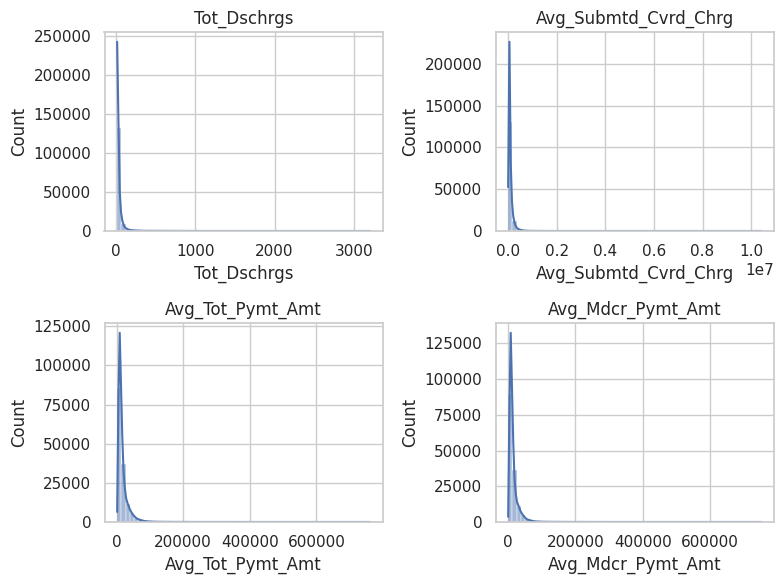

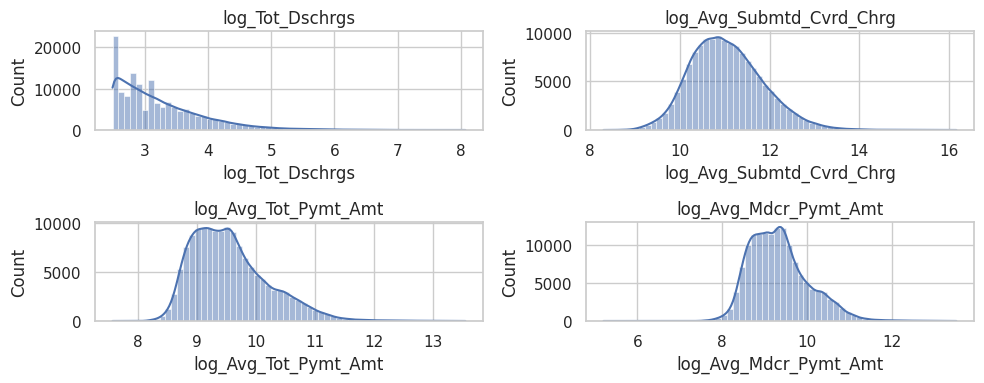

In [15]:
# Visually Explore the Distribution via Graph
fig, axes = plt.subplots(2, 2, figsize=(8, 6))
for ax, col in zip(axes.flat, cost_cols):
    sns.histplot(df[col], bins=60, kde=True, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()


# Log-transform to check for a more normal-looking distribution
for col in cost_cols:
    df[f'log_{col}'] = np.log1p(df[col])
fig, axes = plt.subplots(2, 2, figsize=(10, 4))
log_cols = [ 'log_Tot_Dschrgs','log_Avg_Submtd_Cvrd_Chrg', 'log_Avg_Tot_Pymt_Amt', 'log_Avg_Mdcr_Pymt_Amt']
for ax, col in zip(axes.flat, log_cols):
    sns.histplot(df[col], bins=60, kde=True, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()


> **Observation:** The raw histograms confirm severe right-skew for `Tot_Dschrgs`, `Avg_Submtd_Cvrd_Chrg`, `Avg_Tot_Pymt_Amt`, and `Avg_Mdcr_Pymt_Amt` — a tall spike at low values with a long thin tail out to the multi-hundred-thousand/million-dollar extremes. Applying `log1p` to each column pulls the distributions much closer to a bell shape, which is why the log-transformed versions (`log_Avg_Submtd_Cvrd_Chrg`, etc.) are used later as model inputs instead of the raw dollar values.

### 1.7 Basic exploration: correlation & the markup gap (first look)
A first look at how the cost metrics relate to each other, before the formal payment-gap analysis in Section 6.

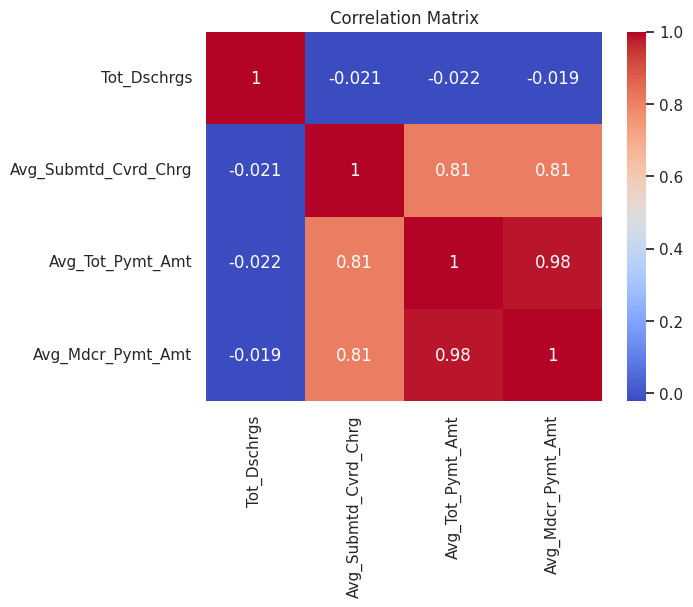

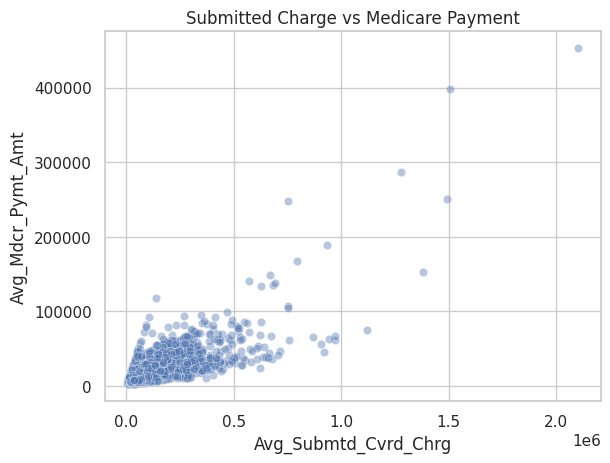

<Axes: xlabel='Markup_Ratio', ylabel='Count'>

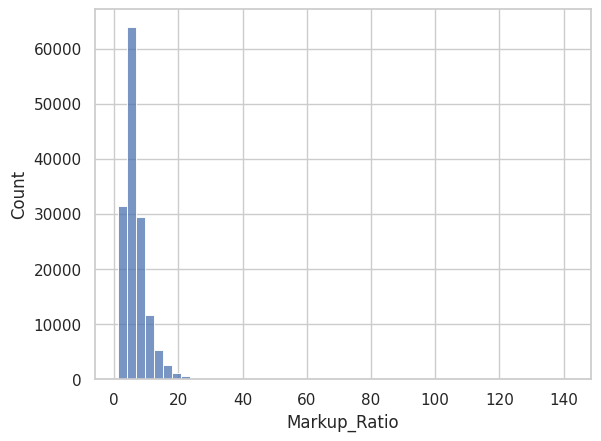

In [16]:
num_cols = ['Tot_Dschrgs','Avg_Submtd_Cvrd_Chrg','Avg_Tot_Pymt_Amt','Avg_Mdcr_Pymt_Amt']
df[num_cols].describe()
#1. Correlation among numeric metrics
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

# 2. Submitted charge vs Medicare payment (markup gap)
sns.scatterplot(data=df.sample(5000, random_state=1),
                 x='Avg_Submtd_Cvrd_Chrg', y='Avg_Mdcr_Pymt_Amt', alpha=0.4)
plt.title('Submitted Charge vs Medicare Payment')
plt.show()

# 3. Markup ratio — how much hospitals bill vs what Medicare actually pays
df['Markup_Ratio'] = df['Avg_Submtd_Cvrd_Chrg'] / df['Avg_Mdcr_Pymt_Amt']
df['Markup_Ratio'].describe()
sns.histplot(df['Markup_Ratio'], bins=50)

> **Observation:** Submitted charge and Medicare payment are positively correlated but far from 1-to-1 — the scatter plot shows a wide, fan-shaped spread rather than a tight line, and the markup-ratio histogram is heavily right-skewed with most hospitals clustered between 3x–8x and a long tail beyond 20x. This first look is explored properly (with the gap quantified in dollars and percentages) in Section 6.

### 1.8 Categorical exploration — where the data concentrates
1. Top states by provider-DRG record count
2. Provider location (RUCA) distribution
3. Most common DRGs


Top 10 States by Provider-DRG Record Count:


,count
Rndrng_Prvdr_State_Abrvtn,
CA,12915
FL,12004
TX,9929
NY,8347
PA,6977


Provider RUCA Description Counts:


,count
Rndrng_Prvdr_RUCA_Desc,
"Metropolitan area core: primary flow within an urbanized area of 50,000 and greater",127034
"Micropolitan area core: primary flow within an urban cluster of 10,000 to 49,999",10394
"Secondary flow 30% to <50% to a larger urbanized area of 50,000 and greater",2415
"Metropolitan area high commuting: primary flow 30% or more to a urbanized area of 50,000 and greater",2243
"Small town core: primary flow within an urban cluster of 2,500 to 9,999",1463


Top 5 Most Common DRG Descriptions:


,count
DRG_Desc,
SEPTICEMIA OR SEVERE SEPSIS WITHOUT MV >96 HOURS WITH MCC,2662
HEART FAILURE AND SHOCK WITH MCC,2625
RESPIRATORY INFECTIONS AND INFLAMMATIONS WITH MCC,2460
SIMPLE PNEUMONIA AND PLEURISY WITH MCC,2407
SEPTICEMIA OR SEVERE SEPSIS WITHOUT MV >96 HOURS WITHOUT MCC,2227


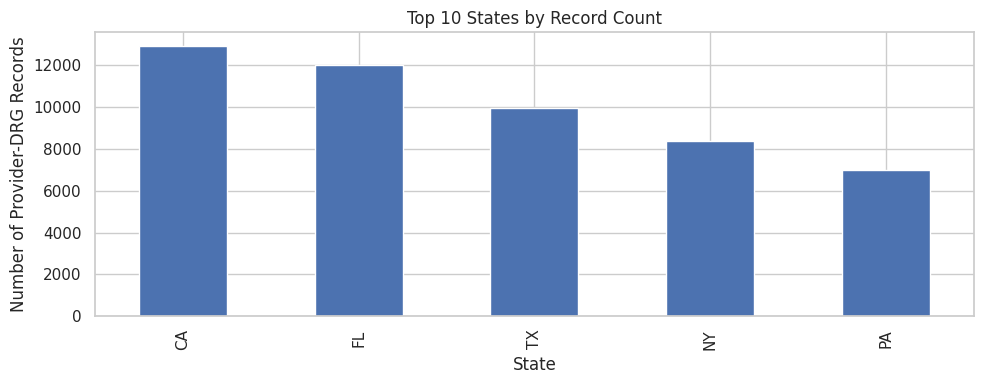

In [17]:
from IPython.display import display
import matplotlib.pyplot as plt

#1. Top 10 states by provider-DRG records
print("Top 10 States by Provider-DRG Record Count:")
display(df['Rndrng_Prvdr_State_Abrvtn'].value_counts().head(5))


#2. Provider location (RUCA description) distribution
print("Provider RUCA Description Counts:")
display(df['Rndrng_Prvdr_RUCA_Desc'].value_counts().head(5))


#3. Most common DRG descriptions
print("Top 5 Most Common DRG Descriptions:")
display(df['DRG_Desc'].value_counts().head(5))


#4. Plot Top 10 states
plt.figure(figsize=(10,4))

df['Rndrng_Prvdr_State_Abrvtn'].value_counts().head(5).plot(
    kind='bar'
)
plt.title('Top 10 States by Record Count')
plt.xlabel('State')
plt.ylabel('Number of Provider-DRG Records')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

> **Observation:** Records concentrate in the largest states (CA, FL, TX, NY, PA), and the overwhelming majority of hospitals sit in "Metropolitan area core" locations (127,034 of 146,142 rows) — rural/small-town providers are a small minority of the dataset by row count, so rural findings later (Sections 3–6) should be read as directionally reliable but based on comparatively few hospitals.

## 2. Outlier Detection in Cost Columns

## Set 2 — Outlier detection in cost columns

Using the **IQR** rule on `Avg_Submtd_Cvrd_Chrg` and `Avg_Mdcr_Pymt_Amt` to flag extreme provider + DRG cases.



1.   Using Box Plot
2.   Apply IQR

For this dataset, IQR is the better choice — but here's why:

Z-score (mean ± 2·std) : Assumes data is roughly normally distributed
Uses mean and standard deviation — both get dragged around by extreme values themselves (a single $700K DRG payment inflates the mean and std, which then hides other outliers)
Works fine on symmetric, bell-shaped data

IQR (Q1/Q3-based)

No distribution assumption
Uses median-based quantiles (Q1, Q3), which extreme values barely affect
Handles skewed data well

Your cost data is heavily right-skewed — most hospitals cluster at low-to-moderate cost, but a few DRGs/hospitals run extremely high (that $10M max charge, $600K max payment we saw earlier).

### 2.1 Boxplots — a first visual scan for outliers

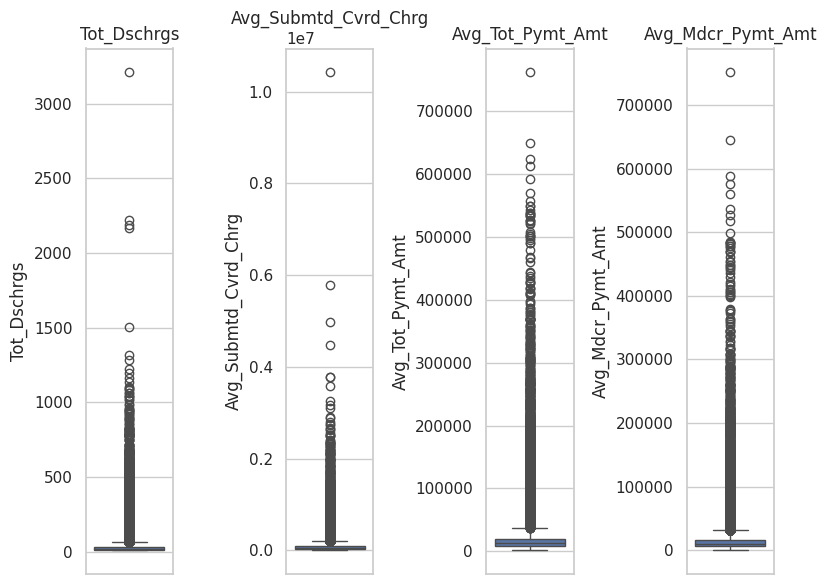

In [18]:
# Boxplots to spot outliers
fig, axes = plt.subplots(1, 4, figsize=(8, 6))
for ax, col in zip(axes, num_cols):
    sns.boxplot(y=df[col], ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

> **Observation:** All four cost columns show the classic right-skew fingerprint on a boxplot — a compressed box near zero and a long scatter of points far above the upper whisker — confirming that a distribution-free method like IQR (rather than a mean/std-based z-score) is the right choice for flagging outliers here.

### 2.2 IQR outlier rule — applied to the whole column

In [19]:
# 1st create a IQR outlier funcation
def iqr_outliers(series):
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    return (series < lower) | (series > upper)

#2 The len(x) >= 10 just skips DRGs with too few hospitals billing them to compare fairly)
df['is_outlier'] = df.groupby('DRG_Cd')['Avg_Tot_Pymt_Amt'] \
                      .transform(lambda x: iqr_outliers(x) if len(x) >= 10 else False)

#3. check % of outlier rows
for col in ['Avg_Submtd_Cvrd_Chrg', 'Avg_Mdcr_Pymt_Amt']:
    mask = iqr_outliers(df[col])
    print(f'{col}: {mask.sum()} outliers ({mask.mean()*100:.1f}% of rows)')


Avg_Submtd_Cvrd_Chrg: 11421 outliers (7.8% of rows)
Avg_Mdcr_Pymt_Amt: 13512 outliers (9.2% of rows)


> **Observation:** Run naively across the whole dataset, the IQR rule flags **7.8%** of rows on submitted charge and **9.2%** on Medicare payment as outliers. But this pools every DRG together — a routine, cheap diagnosis and a complex, expensive one are being judged against the same fence, which risks flagging entire expensive-but-normal DRGs rather than genuinely unusual pricing within a DRG.

### 2.3 IQR outlier rule — applied *within* each DRG (peer group)

**Question 1: Apply IQR WITHIN each DRG (peer group)**

Why not run it on the whole column directly? Because cost naturally differs
by DRG (a brain surgery DRG costs way more than a routine one). Comparing a
hospital to the wrong peers would flag "expensive" DRGs as outliers even
when every hospital billing them looks similar. So we group by DRG first,
then apply your same function inside each group.


In [22]:

df['is_outlier'] = df.groupby('DRG_Cd')['Avg_Tot_Pymt_Amt'] \
                      .transform(lambda x: iqr_outliers(x) if len(x) >= 10 else False)

print(f"Total rows: {len(df)}")
print(f"Outlier rows: {df['is_outlier'].sum()} ({df['is_outlier'].mean()*100:.1f}%)")

Total rows: 146142
Outlier rows: 7629 (5.2%)


In [23]:

df['is_outlier'] = df.groupby('DRG_Cd')['Avg_Mdcr_Pymt_Amt'] \
                      .transform(lambda x: iqr_outliers(x) if len(x) >= 10 else False)

print(f"Total rows: {len(df)}")
print(f"Outlier rows: {df['is_outlier'].sum()} ({df['is_outlier'].mean()*100:.1f}%)")

Total rows: 146142
Outlier rows: 7502 (5.1%)


In [24]:
df['is_outlier'] = df.groupby('DRG_Cd')['Avg_Submtd_Cvrd_Chrg'] \
                      .transform(lambda x: iqr_outliers(x) if len(x) >= 10 else False)

print(f"Total rows: {len(df)}")
print(f"Outlier rows: {df['is_outlier'].sum()} ({df['is_outlier'].mean()*100:.1f}%)")

Total rows: 146142
Outlier rows: 7350 (5.0%)


> **Observation:** Once outliers are judged against same-DRG peers instead of the whole dataset, the flagged share drops to a more defensible **5.2% (payment)** / **5.0% (submitted charge)** of rows — this is the apples-to-apples version and is used for all provider-level rollups below.

### 2.4 Roll up to the provider level
A provider is flagged as a cost outlier if a meaningful share (≥15%) of its billed DRGs were flagged as peer-group outliers.

In [25]:
prov = df.groupby(['Rndrng_Prvdr_CCN','Rndrng_Prvdr_Org_Name','Rndrng_Prvdr_State_Abrvtn']).agg(
    n_drgs=('is_outlier','size'), n_outlier_drgs=('is_outlier','sum')).reset_index()
prov['outlier_rate'] = prov['n_outlier_drgs'] / prov['n_drgs']
outlier_providers = prov[prov['outlier_rate'] >= 0.15].sort_values('outlier_rate', ascending=False)
print(f"\nProvider outliers (>=15% of DRGs flagged): {len(outlier_providers)}")
print(outlier_providers.head(15).to_string(index=False))


Provider outliers (>=15% of DRGs flagged): 201
 Rndrng_Prvdr_CCN                              Rndrng_Prvdr_Org_Name Rndrng_Prvdr_State_Abrvtn  n_drgs  n_outlier_drgs  outlier_rate
            50125                Regional Medical Center Of San Jose                        CA      52              52          1.00
            50464                             Doctors Medical Center                        CA      91              91          1.00
            50589                        Uci Health  Placentia Linda                        CA      10              10          1.00
            50118                        Doctors Hospital Of Manteca                        CA      15              15          1.00
            50779         Martin Luther King, Jr. Community Hospital                        CA      18              18          1.00
           310040 Carepoint Health-Hoboken University Medical Center                        NJ       4               4          1.00
           110113    

> **Observation:** **201 hospitals (out of ~2,900)** have at least 15% of their DRGs flagged as peer-group outliers — several (e.g., Regional Medical Center of San Jose, Doctors Medical Center CA, Martin Luther King Jr. Community Hospital) are flagged on **100%** of the DRGs they bill, indicating a hospital-wide pricing pattern rather than one or two unusual procedures.

### 2.5 Regional pattern of provider-level outliers

In [26]:
# ---- Step 5: Regional pattern ----
state_summary = prov.assign(is_out = prov['outlier_rate']>=0.15) \
                     .groupby('Rndrng_Prvdr_State_Abrvtn')['is_out'] \
                     .agg(['sum','count','mean'])
state_summary = state_summary[state_summary['count']>=5].sort_values('mean', ascending=False)
print("\nOutlier rate by state (states with >=5 hospitals):")
print(state_summary.head(10))


Outlier rate by state (states with >=5 hospitals):
                           sum  count  mean
Rndrng_Prvdr_State_Abrvtn                  
NV                           9     22  0.41
NJ                          15     63  0.24
FL                          39    164  0.24
CA                          58    275  0.21
DC                           1      6  0.17
TX                          32    238  0.13
AK                           1      8  0.12
CO                           6     48  0.12
MS                           5     50  0.10
AZ                           4     57  0.07


Observation: Avg_Submtd_Cvrd_Chrg: 11438 outliers (7.8% of rows)
Avg_Mdcr_Pymt_Amt: 13541 outliers (9.2% of rows) mens

The output means:

1. Avg_Submtd_Cvrd_Chrg: 11438 outliers (7.8% of rows)

Avg_Submtd_Cvrd_Chrg = Average Submitted Covered Charge (the average amount a hospital/provider billed for a service).

The IQR method found 11,438 rows where the charge amount is unusually different from most other providers.

These 11,438 rows represent 7.8% of all records in your dataset.

2. Avg_Mdcr_Pymt_Amt: 13541 outliers (9.2% of rows)

Avg_Mdcr_Pymt_Amt = Average Medicare Payment Amount (the amount Medicare actually paid the provider).

The IQR method found 13,541 rows where Medicare payments are unusually different from the majority of providers.
These represent 9.2% of all records.


## 3. Insight Discovery (A) — Cost Variation Across Providers & Regions

This is a single-year snapshot, so no time-trend analysis applies; instead we use variation and grouped comparisons, which are the appropriate methods here.

- **Q1.** Which services show the highest cost variation *between providers*?
- **Q2.** Are there regional patterns in cost, once the service itself is held constant?

### 3.1 Q1 — DRG cost variation between providers (coefficient of variation)

**Q1:** Which 'services'(DRG) show the highest cost variation *between providers*?


**Method:** For each DRG, compute the **coefficient of variation** (CV = std ÷ mean) of `Avg_Submtd_Cvrd_Chrg` across all providers performing that service. CV is scale-independent, so a $30K-average service and a $300K-average service can be compared fairly. Restricted to DRGs with at least 30 providers so the variation reflects a real spread, not small-sample noise.

In [27]:
drg_var = df.groupby('DRG_Desc').agg(
    n_providers=('Rndrng_Prvdr_CCN', 'nunique'),
    mean_charge=('Avg_Submtd_Cvrd_Chrg', 'mean'),
    std_charge=('Avg_Submtd_Cvrd_Chrg', 'std'),
    total_discharges=('Tot_Dschrgs', 'sum')
)
drg_var = drg_var[drg_var['n_providers'] >= 30].copy()
drg_var['cv'] = drg_var['std_charge'] / drg_var['mean_charge']
drg_var['max_min_ratio'] = df.groupby('DRG_Desc')['Avg_Submtd_Cvrd_Chrg'].apply(lambda x: x.max()/x.min())
drg_var = drg_var.sort_values('cv', ascending=False)

print('Top 10 DRGs by cost variation (CV) across providers:')
drg_var.head(10)[['n_providers','mean_charge','cv','max_min_ratio','total_discharges']]


Top 10 DRGs by cost variation (CV) across providers:


,n_providers,mean_charge,cv,max_min_ratio,total_discharges
DRG_Desc,,,,,
CARDIAC CONGENITAL AND VALVULAR DISORDERS WITH MCC,38,"110,064.44",1.77,80.28,577
INTERSTITIAL LUNG DISEASE WITH MCC,192,"88,608.99",1.22,90.00,3222
MAJOR HEMATOLOGICAL AND IMMUNOLOGICAL DIAGNOSES EXCEPT SICKLE CELL CRISIS AND COAGULATIO,227,"92,091.90",0.90,51.09,5609
WOUND DEBRIDEMENT AND SKIN GRAFT EXCEPT HAND FOR MUSCULOSKELETAL AND CONNECTIVE TISSUE D,138,"199,508.77",0.87,38.55,2835
COAGULATION DISORDERS,456,"77,942.25",0.85,47.32,9468
PSYCHOSES,558,"47,468.21",0.85,44.96,38881
CRANIAL AND PERIPHERAL NERVE DISORDERS WITH MCC,58,"76,155.45",0.84,30.31,961
OTHER CIRCULATORY SYSTEM O.R. PROCEDURES,138,"170,304.62",0.81,39.75,2304
"ALCOHOL, DRUG ABUSE OR DEPENDENCE WITH REHABILITATION THERAPY",48,"52,975.32",0.79,15.01,3165


In [28]:
print('Bottom 10 DRGs — most consistently priced across providers:')
drg_var.tail(10)[['n_providers','mean_charge','cv','max_min_ratio','total_discharges']]


Bottom 10 DRGs — most consistently priced across providers:


,n_providers,mean_charge,cv,max_min_ratio,total_discharges
DRG_Desc,,,,,
PERIPHERAL VASCULAR DISORDERS WITHOUT CC/MCC,32,"36,169.42",0.46,5.87,468
"PANCREAS, LIVER AND SHUNT PROCEDURES WITH CC",128,"146,577.46",0.45,14.91,2933
SOFT TISSUE PROCEDURES WITH CC,30,"92,609.24",0.45,6.13,404
RENAL FAILURE WITHOUT CC/MCC,84,"26,937.02",0.44,9.25,1179
OTHER O.R. PROCEDURES FOR MULTIPLE SIGNIFICANT TRAUMA WITH MCC,41,"344,582.06",0.43,4.87,592
AORTIC AND HEART ASSIST PROCEDURES EXCEPT PULSATION BALLOON WITH MCC,35,"370,222.25",0.42,5.43,542
DISORDERS OF THE BILIARY TRACT WITHOUT CC/MCC,33,"45,849.28",0.42,5.49,463
NONSPECIFIC CVA AND PRECEREBRAL OCCLUSION WITHOUT INFARCTION WITHOUT MCC,40,"62,163.81",0.42,9.73,606
MAJOR BLADDER PROCEDURES WITH CC,64,"161,566.26",0.41,7.57,1546


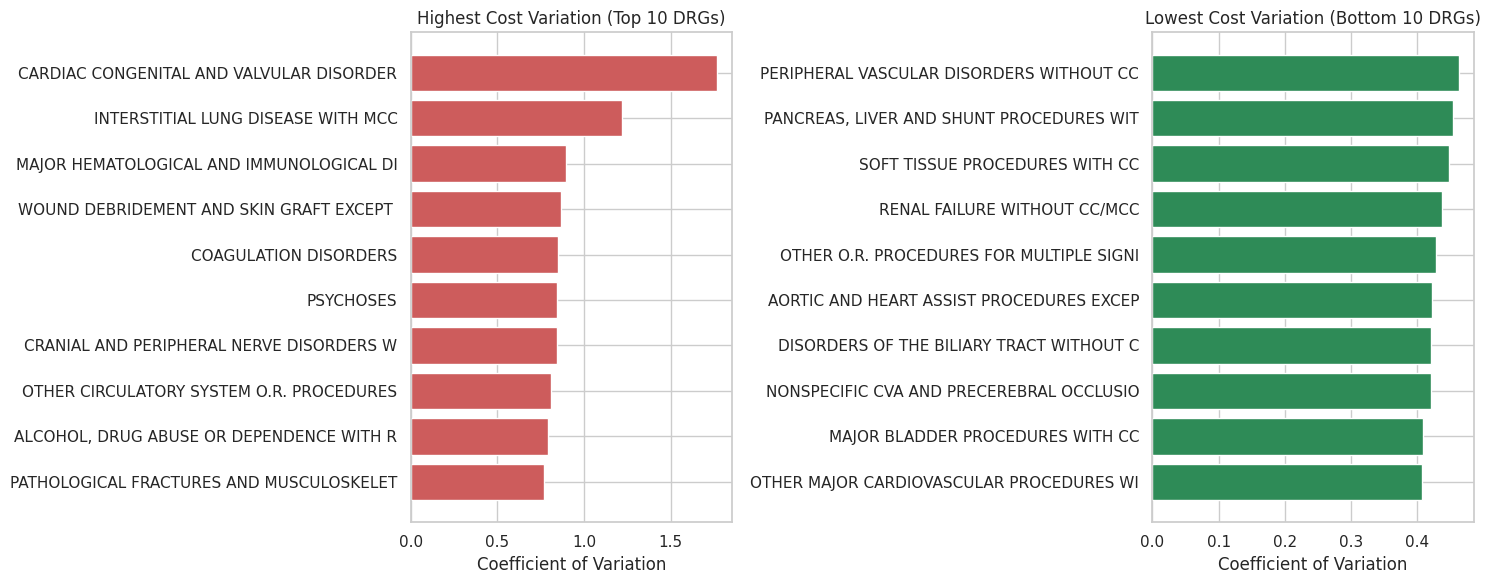

In [29]:
# Visualize highest vs lowest variation services
top10 = drg_var.head(10).sort_values('cv')
bottom10 = drg_var.tail(10).sort_values('cv')

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
axes[0].barh(top10.index.str.slice(0, 40), top10['cv'], color='indianred')
axes[0].set_title('Highest Cost Variation (Top 10 DRGs)')
axes[0].set_xlabel('Coefficient of Variation')

axes[1].barh(bottom10.index.str.slice(0, 40), bottom10['cv'], color='seagreen')
axes[1].set_title('Lowest Cost Variation (Bottom 10 DRGs)')
axes[1].set_xlabel('Coefficient of Variation')
plt.tight_layout()
plt.show()


Observation:
- 1.7 CV and 1.2 CV -- have it's finding the diagnoses where hospitals disagree with each other the most, proportionally

CV tells you: "how much do hospitals' average payments for this specific condition swing around, relative to the typical cost of that condition?"

**Low CV (like 0.2) **→ most hospitals charge Medicare *about the same amount for treating that condition*. Predictable.

**High CV (like 1.0+)** → payments for that condition are *all over the place *— some hospitals *get paid way more than others* for the "same" DRG code.


### 3.2 Q2 — Regional variation for a single, fixed DRG

**Q2:** Are there regional patterns in cost, once the service itself is held constant?

**Regional comparison for the same DRG**

**Question:** For a single, common DRG, how much does the average charge
differ from state to state?

**Method:** Pick the DRG with the largest number of hospitals reporting it
 (so it's genuinely common everywhere, not a niche procedure), group by
state, and compare the average submitted charge and average Medicare
 payment.

  Restrict to states with a reasonable number of hospitals so a
 single-hospital state doesn't produce a misleading extreme.

In [30]:
# First Identify the highest-volume DRG to hold the service constant
top_drg_by_volume = df.groupby('DRG_Desc')['Tot_Dschrgs'].sum().sort_values(ascending=False)
print('Top 5 DRGs by total discharges:')
top_drg_by_volume.head(5)


Top 5 DRGs by total discharges:


,Tot_Dschrgs
DRG_Desc,
SEPTICEMIA OR SEVERE SEPSIS WITHOUT MV >96 HOURS WITH MCC,561193
HEART FAILURE AND SHOCK WITH MCC,319440
RESPIRATORY INFECTIONS AND INFLAMMATIONS WITH MCC,166444
SIMPLE PNEUMONIA AND PLEURISY WITH MCC,125717
SEPTICEMIA OR SEVERE SEPSIS WITHOUT MV >96 HOURS WITHOUT MCC,104366


In [31]:
# Then check the high variance in cost for Regional or states
drg_name = top_drg_by_volume.index[0]
sub = df[df['DRG_Desc'] == drg_name]

state_this_drg = sub.groupby('Rndrng_Prvdr_State_Abrvtn').agg(
    n_providers=('Rndrng_Prvdr_CCN', 'nunique'),
    avg_charge=('Avg_Submtd_Cvrd_Chrg', 'mean'),
    avg_mdcr_payment=('Avg_Mdcr_Pymt_Amt', 'mean'),
    avg_markup=('Markup_Ratio', 'mean')
)
state_this_drg = state_this_drg[state_this_drg['n_providers'] >= 10].sort_values('avg_charge', ascending=False)

print(f'Service held constant: {drg_name}')
print('Top 10 states by avg charge for this same service:')
state_this_drg.head()


Service held constant: SEPTICEMIA OR SEVERE SEPSIS WITHOUT MV >96 HOURS WITH MCC
Top 10 states by avg charge for this same service:


,n_providers,avg_charge,avg_mdcr_payment,avg_markup
Rndrng_Prvdr_State_Abrvtn,,,,
NV,21,"173,926.47","14,919.89",12.08
NJ,62,"141,023.94","17,083.95",8.39
CA,263,"122,095.63","19,156.90",6.48
FL,162,"108,253.15","13,019.94",8.41
CO,42,"94,480.03","14,475.87",6.79


In [32]:
print('Bottom 10 states by avg charge for this same service:')
state_this_drg.tail(10)


Bottom 10 states by avg charge for this same service:


,n_providers,avg_charge,avg_mdcr_payment,avg_markup
Rndrng_Prvdr_State_Abrvtn,,,,
WI,61,"49,667.71","13,423.99",3.71
WV,20,"49,484.40","12,604.69",3.91
MN,44,"49,425.13","15,210.27",3.30
UT,29,"49,020.93","13,091.39",3.84
MI,81,"48,186.82","14,123.19",3.44
ME,17,"45,382.55","16,183.38",2.94
MT,11,"41,654.89","13,565.54",3.10
IA,31,"41,223.67","12,924.91",3.26
MA,50,"40,924.62","16,758.18",2.36


In [33]:
ratio = state_this_drg['avg_charge'].max() / state_this_drg['avg_charge'].min()
print(f'Highest-billing state charges {ratio:.1f}x more than the lowest-billing state, for the identical DRG.')


Highest-billing state charges 6.2x more than the lowest-billing state, for the identical DRG.


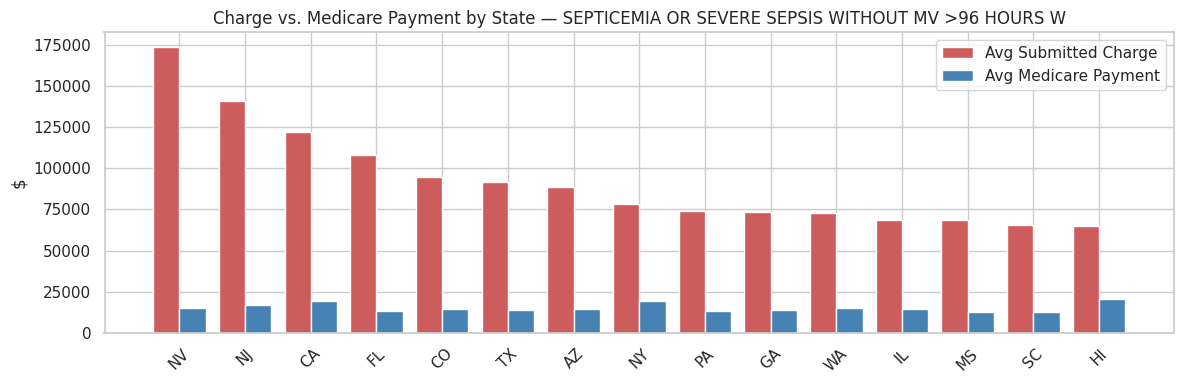

In [35]:
# Visualize: charge vs Medicare payment by state, for the same service
plot_df = state_this_drg.sort_values('avg_charge', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(12, 4))
x = np.arange(len(plot_df))
width = 0.4
ax.bar(x - width/2, plot_df['avg_charge'], width, label='Avg Submitted Charge', color='indianred')
ax.bar(x + width/2, plot_df['avg_mdcr_payment'], width, label='Avg Medicare Payment', color='steelblue')
ax.set_xticks(x)
ax.set_xticklabels(plot_df.index, rotation=45)
ax.set_ylabel('$')
ax.set_title(f'Charge vs. Medicare Payment by State — {drg_name[:50]}')
ax.legend()
plt.tight_layout()
plt.show()


Observation:
174K in Nevadadown to about 28K in Maryland, a ~6x gap. By contrast, the actual Medicare payment barely moves across states (roughly  15K– 23K, less than a 2x range), because CMS payment formulas are cost/wage-index adjusted and fairly standardized nationally.

The gap is therefore driven almost entirely by billing behavior, not the underlying cost of care. Notably, Maryland — the lowest-markup state in the analysis (~1.2x) — is a known real-world outlier: it operates under a unique all-payer rate-setting system regulated by the state, which is a plausible explanation for why its markup is so much lower than everywhere else.

## 4. Insight Discovery (B) — Hospital Volume vs. Charge/Payment Behavior

**Q1. Do high-volume hospitals achieve economies of scale?**

**Method:** Aggregate to the provider level (sum discharges across all DRGs, average charges/payments/markup), split providers into quartiles by total discharge volume, and compare charge/payment/markup across tiers. Cross-check with a direct correlation, and track the number of distinct DRGs each hospital treats, since case-mix breadth is the key confound here.

In [ ]:
prov = df.groupby(['Rndrng_Prvdr_CCN', 'Rndrng_Prvdr_Org_Name', 'Rndrng_Prvdr_State_Abrvtn']).agg(
    total_discharges=('Tot_Dschrgs', 'sum'),
    avg_charge=('Avg_Submtd_Cvrd_Chrg', 'mean'),
    avg_mdcr_payment=('Avg_Mdcr_Pymt_Amt', 'mean'),
    avg_markup=('Markup_Ratio', 'mean'),
    n_drgs=('DRG_Cd', 'nunique')
).reset_index()

prov['volume_tier'] = pd.qcut(prov['total_discharges'], q=4,
                               labels=['Low (Q1)', 'Med-Low (Q2)', 'Med-High (Q3)', 'High (Q4)']) # spliting in 4 group based on discharge number or volumne per hospital

volume_summary = prov.groupby('volume_tier', observed=True).agg(
    n_providers=('Rndrng_Prvdr_CCN', 'count'),
    avg_total_discharges=('total_discharges', 'mean'),
    avg_charge=('avg_charge', 'mean'),
    avg_mdcr_payment=('avg_mdcr_payment', 'mean'),
    avg_markup=('avg_markup', 'mean'),
    avg_n_drgs=('n_drgs', 'mean')
)
print("Charge/payment/markup by hospital volume tier:")
print(volume_summary.to_string())

Charge/payment/markup by hospital volume tier:
               n_providers  avg_total_discharges  avg_charge  avg_mdcr_payment  avg_markup  avg_n_drgs
volume_tier                                                                                           
Low (Q1)               733                111.70   51,318.16         12,580.45        4.10        5.01
Med-Low (Q2)           733                525.22   62,458.93         11,776.11        5.63       19.93
Med-High (Q3)          734              1,472.94   74,890.67         12,351.03        6.42       49.77
High (Q4)              732              4,651.01   96,269.24         16,083.16        6.44      124.77


In [ ]:
vol_corr = prov['total_discharges'].corr(prov['avg_charge'])
print(f"\nCorrelation(total_discharges, avg_charge) = {vol_corr:.3f}")


Correlation(total_discharges, avg_charge) = 0.309


In [ ]:
prov.head()

,Rndrng_Prvdr_CCN,Rndrng_Prvdr_Org_Name,Rndrng_Prvdr_State_Abrvtn,total_discharges,avg_charge,avg_mdcr_payment,avg_markup,n_drgs,volume_tier
0,10001,Southeast Health Medical Center,AL,2972,"80,198.69","14,396.45",5.40,91,High (Q4)
1,10005,Marshall Medical Centers South Campus,AL,787,"20,590.60","7,429.59",2.86,31,Med-Low (Q2)
2,10006,North Alabama Medical Center,AL,2652,"61,851.32","10,477.87",5.94,76,High (Q4)
3,10007,Mizell Memorial Hospital,AL,126,"13,460.97","8,569.17",1.67,7,Low (Q1)
4,10008,Crenshaw Community Hospital,AL,11,"14,457.73","5,334.18",2.71,1,Low (Q1)


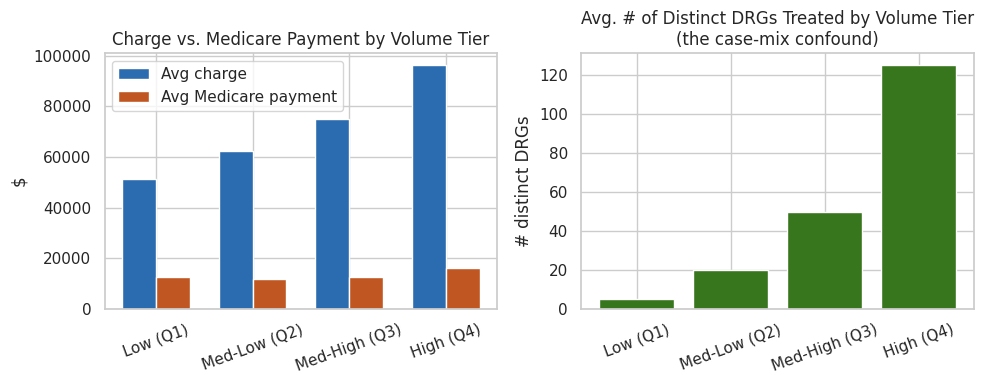

In [ ]:

import numpy as np

x = np.arange(len(volume_summary.index))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(x - width/2, volume_summary["avg_charge"], width, color="#2b6cb0", label="Avg charge")
axes[0].bar(x + width/2, volume_summary["avg_mdcr_payment"], width, color="#c05621", label="Avg Medicare payment")
axes[0].set_title("Charge vs. Medicare Payment by Volume Tier")
axes[0].set_ylabel("$")
axes[0].set_xticks(x)
axes[0].set_xticklabels(volume_summary.index.astype(str), rotation=20)
axes[0].legend()

axes[1].bar(volume_summary.index.astype(str), volume_summary["avg_n_drgs"], color="#38761d")
axes[1].set_title("Avg. # of Distinct DRGs Treated by Volume Tier\n(the case-mix confound)")
axes[1].set_ylabel("# distinct DRGs")
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()


Observation: For each volume tier, it compares two numbers:

Blue = average submitted charge (what the hospital bills)
Orange = average Medicare payment (what Medicare actually pays)

The pattern: as hospital volume goes up (Low → High), average charges climb steadily (~$50k → ~$95k).

While Medicare payments stay almost flat (~$12k to16k) regardless of volume.

That's the core finding for your research question —

**"Do high-volume hospitals achieve economies of scale?"** The answer this chart suggests is **No — busier hospitals don't bill less per patient;** if anything they bill more, even though Medicare's actual reimbursement barely moves.

So the markup ratio (charge ÷ payment) is likely growing with volume, not shrinking as you'd expect if scale brought efficiency.


What the right chart shows — the confound

This is the important caveat your code comment flags: "the case-mix confound."

High-volume hospitals aren't just "doing more of the same" — they treat a much wider variety of DRGs (diagnosis-related groups). Look at the jump: Low-volume hospitals treat ~5 distinct DRGs on average, High-volume hospitals treat ~125.

Why this matters: high-volume hospitals are very likely large academic/tertiary medical centers that handle complex, specialized cases.

So higher charges at high-volume hospitals might reflect case-mix complexity, not lack of scale efficiency, or some mix of both.


### 4.1 Does charging more actually get a hospital more Medicare payment?

**Question 2. Does charging more actually get a hospital more Medicare payment?**

Is there a real, dollar-for-dollar relationship between what a hospital bills and what Medicare actually pays it?

**Method:** Scatter submitted charge (x) against Medicare payment (y), with a 1:1 reference line showing what "you get what you charge" would
look like. Compute the correlation and the markup ratio distribution.

Correlation (submitted charge vs Medicare payment): 0.811

Markup ratio summary (submitted charge / Medicare payment):
count   146,142.00
mean          6.35
std           3.61
min           1.03
25%           4.06
50%           5.52
75%           7.68
max         141.51
Name: Markup_Ratio, dtype: float64
module://matplotlib_inline.backend_inline


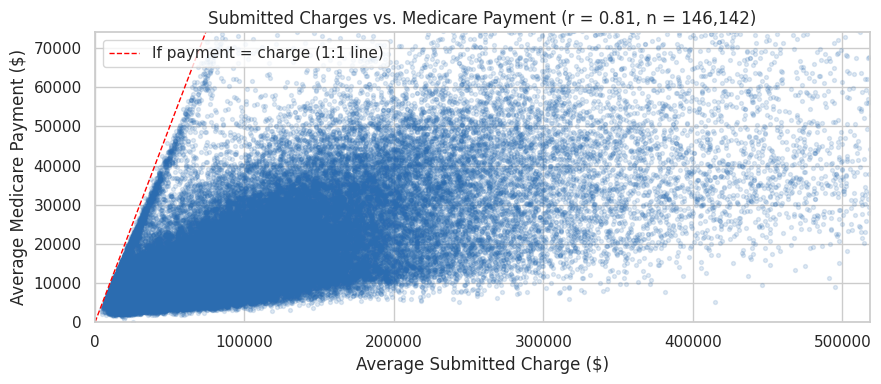

In [36]:
# %%
corr = df["Avg_Submtd_Cvrd_Chrg"].corr(df["Avg_Mdcr_Pymt_Amt"])
print(f"Correlation (submitted charge vs Medicare payment): {corr:.3f}")
print("\nMarkup ratio summary (submitted charge / Medicare payment):")
print(df["Markup_Ratio"].describe())

# %%
import matplotlib
print(matplotlib.get_backend())
fig, ax = plt.subplots(figsize=(9, 4))
ax.scatter(df["Avg_Submtd_Cvrd_Chrg"], df["Avg_Mdcr_Pymt_Amt"], alpha=0.15, s=8, color="#2b6cb0")
max_val = df["Avg_Submtd_Cvrd_Chrg"].quantile(0.99)
ax.plot([0, max_val], [0, max_val], color="red", linestyle="--", linewidth=1, label="If payment = charge (1:1 line)")
ax.set_xlim(0, max_val)
ax.set_ylim(0, df["Avg_Mdcr_Pymt_Amt"].quantile(0.99))
ax.set_xlabel("Average Submitted Charge ($)")
ax.set_ylabel("Average Medicare Payment ($)")
ax.set_title(f"Submitted Charges vs. Medicare Payment (r = {corr:.2f}, n = {len(df):,})")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

> **Observation:** Submitted charge and Medicare payment correlate at **r = 0.81** — a real but far-from-1:1 relationship. The scatter plot sits well below the 1:1 reference line across the board: billing more is associated with being paid somewhat more, but nowhere near dollar-for-dollar, which is the visual counterpart of the ~6x median markup ratio quantified in Section 6.

## 5. Predictive Modeling — What Drives Cost?

In [38]:

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler

# --- Feature engineering ---
def severity(desc):
    d = str(desc).upper()
    if "WITHOUT CC/MCC" in d or "WITHOUT CC MCC" in d:
        return "No CC/MCC (low acuity)"
    if "WITH MCC" in d:
        return "With MCC (major complication)"
    if "WITH CC" in d:
        return "With CC (complication)"
    return "N/A (severity not coded)"

df["DRG_Severity"] = df["DRG_Desc"].apply(severity)

def urbanicity(ruca):
    if pd.isna(ruca) or ruca == 99:
        return "Unknown"
    if ruca < 4:
        return "Urban (Metro)"
    if ruca < 7:
        return "Micropolitan"
    return "Rural/Small town"

df["Urbanicity"] = df["Rndrng_Prvdr_RUCA"].apply(urbanicity)

region_map = {
    'CT':'Northeast','ME':'Northeast','MA':'Northeast','NH':'Northeast','RI':'Northeast','VT':'Northeast',
    'NJ':'Northeast','NY':'Northeast','PA':'Northeast',
    'IL':'Midwest','IN':'Midwest','MI':'Midwest','OH':'Midwest','WI':'Midwest',
    'IA':'Midwest','KS':'Midwest','MN':'Midwest','MO':'Midwest','NE':'Midwest','ND':'Midwest','SD':'Midwest',
    'DE':'South','FL':'South','GA':'South','MD':'South','NC':'South','SC':'South','VA':'South','DC':'South',
    'WV':'South','AL':'South','KY':'South','MS':'South','TN':'South','AR':'South','LA':'South','OK':'South','TX':'South',
    'AZ':'West','CO':'West','ID':'West','MT':'West','NV':'West','NM':'West','UT':'West','WY':'West',
    'AK':'West','CA':'West','HI':'West','OR':'West','WA':'West',
    'PR':'Territory','VI':'Territory','GU':'Territory','MP':'Territory'
}
df["Region"] = df["Rndrng_Prvdr_State_Abrvtn"].map(region_map).fillna("Other/Territory")

hosp_features = df.groupby("Rndrng_Prvdr_CCN").agg(
    hosp_total_discharges=("Tot_Dschrgs", "sum"),
    hosp_n_drgs=("DRG_Cd", "nunique")
).reset_index()
df = df.merge(hosp_features, on="Rndrng_Prvdr_CCN", how="left")

df["log_charge"] = np.log(df["Avg_Submtd_Cvrd_Chrg"])

# %%
# --- Variance decomposition: DRG identity alone ---
grand_mean = df["log_charge"].mean()
ss_total = ((df["log_charge"] - grand_mean) ** 2).sum()
drg_means = df.groupby("DRG_Cd")["log_charge"].transform("mean")
ss_between_drg = ((drg_means - grand_mean) ** 2).sum()
r2_drg_alone = ss_between_drg / ss_total
print(f"R^2 from DRG identity alone: {r2_drg_alone:.3f}")


R^2 from DRG identity alone: 0.579


In [39]:
#-- Build non-DRG-identity feature set ---
model_df = df[[
    "log_charge", "DRG_Severity", "Urbanicity", "Region",
    "Tot_Dschrgs", "hosp_total_discharges", "hosp_n_drgs"
]].dropna()
model_df["log_row_discharges"] = np.log1p(model_df["Tot_Dschrgs"])
model_df["log_hosp_discharges"] = np.log1p(model_df["hosp_total_discharges"])

cat_cols = ["DRG_Severity", "Urbanicity", "Region"]
num_cols = ["log_row_discharges", "log_hosp_discharges", "hosp_n_drgs"]

X = pd.concat([model_df[num_cols], pd.get_dummies(model_df[cat_cols], drop_first=True)], axis=1)
y = model_df["log_charge"]

# --- Linear regression (standardized -> comparable coefficient magnitudes) ---
scaler = StandardScaler()
X_scaled = X.copy()
X_scaled[num_cols] = scaler.fit_transform(X[num_cols])

lin = LinearRegression().fit(X_scaled, y)
r2_lin = lin.score(X_scaled, y)
print(f"Linear model R^2 (severity+region+urbanicity+volume, no DRG identity): {r2_lin:.3f}")

coef_table = pd.Series(lin.coef_, index=X_scaled.columns).sort_values(key=abs, ascending=False)
print("\nStandardized coefficients (sign = direction, magnitude = strength):")
print(coef_table.to_string())


Linear model R^2 (severity+region+urbanicity+volume, no DRG identity): 0.186

Standardized coefficients (sign = direction, magnitude = strength):
Region_West                                   0.55
Urbanicity_Unknown                            0.38
Urbanicity_Urban (Metro)                      0.29
DRG_Severity_With MCC (major complication)    0.28
DRG_Severity_No CC/MCC (low acuity)          -0.24
hosp_n_drgs                                   0.22
Region_South                                  0.15
DRG_Severity_With CC (complication)          -0.14
Urbanicity_Rural/Small town                  -0.14
Region_Northeast                              0.13
log_row_discharges                           -0.08
log_hosp_discharges                          -0.01



Random Forest R^2: 0.253

Importance grouped by original factor:
hosp_n_drgs           0.38
Region                0.20
DRG_Severity          0.19
log_hosp_discharges   0.13
Urbanicity            0.05
log_row_discharges    0.05


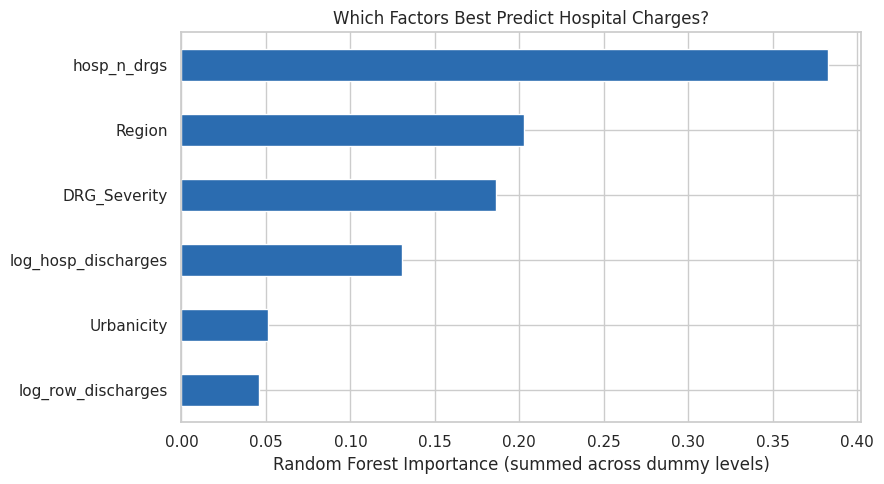

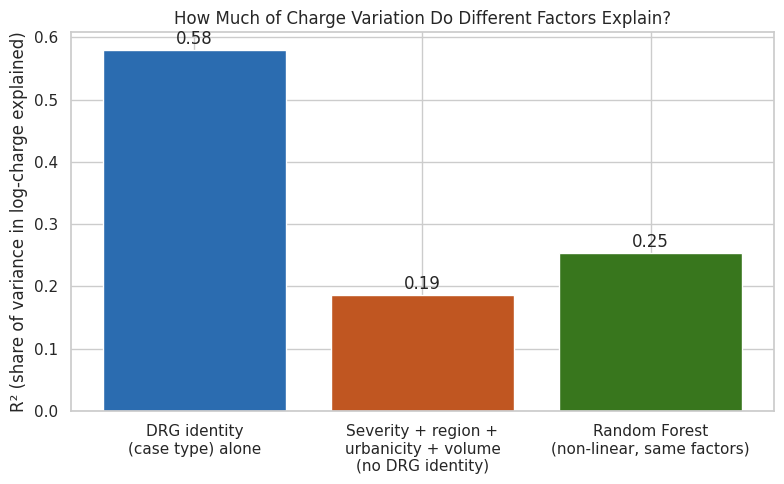

In [40]:

# --- Random Forest cross-check + importance ranking ---
rf = RandomForestRegressor(n_estimators=200, max_depth=8, random_state=42, n_jobs=-1)
rf.fit(X, y)
r2_rf = rf.score(X, y)
print(f"\nRandom Forest R^2: {r2_rf:.3f}")

importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

def parent(col):
    for c in cat_cols:
        if col.startswith(c + "_"):
            return c
    return col

grouped_importance = importances.groupby(parent).sum().sort_values(ascending=False)
print("\nImportance grouped by original factor:")
print(grouped_importance.to_string())

# %%
fig, ax = plt.subplots(figsize=(9, 5))
grouped_importance.sort_values().plot(kind="barh", ax=ax, color="#2b6cb0")
ax.set_xlabel("Random Forest Importance (summed across dummy levels)")
ax.set_title("Which Factors Best Predict Hospital Charges?")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
bars = ["DRG identity\n(case type) alone",
        "Severity + region +\nurbanicity + volume\n(no DRG identity)",
        "Random Forest\n(non-linear, same factors)"]
vals = [r2_drg_alone, r2_lin, r2_rf]
ax.bar(bars, vals, color=["#2b6cb0", "#c05621", "#38761d"])
ax.set_ylabel("R² (share of variance in log-charge explained)")
ax.set_title("How Much of Charge Variation Do Different Factors Explain?")
for i, v in enumerate(vals):
    ax.text(i, v + 0.01, f"{v:.2f}", ha="center")
plt.tight_layout()
plt.show()


> **Observation:** DRG identity alone explains **58%** of the variance in log(charge) (R²=0.579) — largely confirming that *what condition is being treated* is the single biggest driver of the dollar amount billed, as expected. With DRG identity deliberately removed from the feature set (to isolate hospital/market pricing behavior), a linear model using severity, region, urbanicity and volume alone explains **19%** of the remaining variation (R²=0.186), and a non-linear Random Forest on the same features explains **25%** (R²=0.253) — with **hospital case-mix breadth (`hosp_n_drgs`, 38% of importance)** and **Region (20%)** the strongest non-clinical predictors. In other words: after the diagnosis itself, *which hospital and which region* you're treated in matters more than how rural/urban the hospital is or how many patients it sees.

## 6. Deep-Dive — The Billed-vs-Paid Gap

The core question: how much more do hospitals bill than Medicare actually pays?

- `Markup_Ratio` = submitted charge ÷ Medicare payment (how many times over)
- `Payment_Gap` = submitted charge − Medicare payment (dollar gap)
- `Payment_Gap_Pct` = gap as a % of the submitted charge

In [ ]:
df['Markup_Ratio'] = df['Avg_Submtd_Cvrd_Chrg'] / df['Avg_Mdcr_Pymt_Amt']
df['Payment_Gap'] = df['Avg_Submtd_Cvrd_Chrg'] - df['Avg_Mdcr_Pymt_Amt']
df['Payment_Gap_Pct'] = df['Payment_Gap'] / df['Avg_Submtd_Cvrd_Chrg'] * 100

df[['Markup_Ratio', 'Payment_Gap', 'Payment_Gap_Pct']].describe()

,Markup_Ratio,Payment_Gap,Payment_Gap_Pct
count,"146,142.00","146,142.00","146,142.00"
mean,6.35,"75,624.57",78.85
std,3.61,"105,704.45",13.65
min,1.03,732.67,2.91
25%,4.06,"27,026.51",75.35
50%,5.52,"47,737.43",81.89
75%,7.68,"87,664.17",86.98
max,141.51,"9,667,453.74",99.29


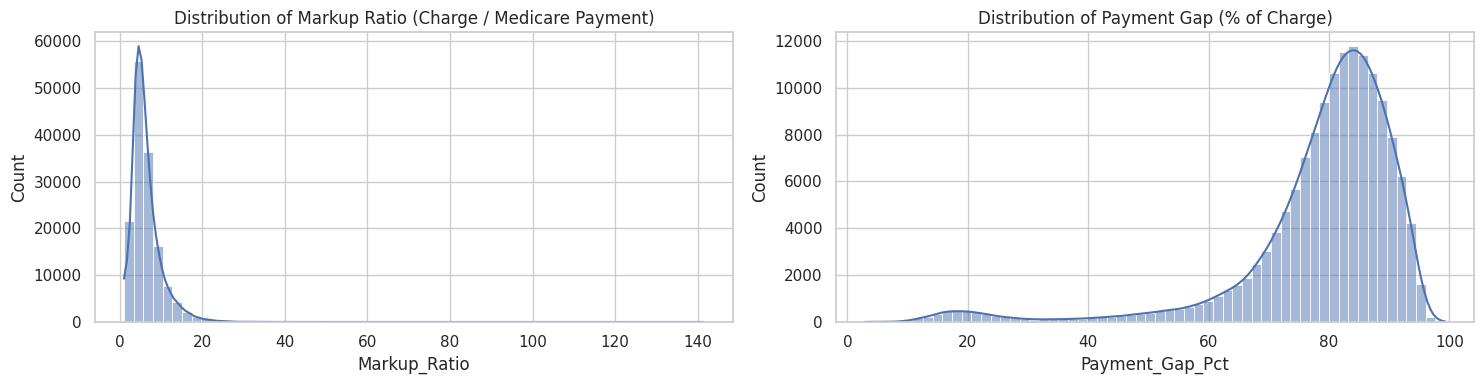

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4))
sns.histplot(df['Markup_Ratio'], bins=60, kde=True, ax=axes[0])
axes[0].set_title('Distribution of Markup Ratio (Charge / Medicare Payment)')
sns.histplot(df['Payment_Gap_Pct'], bins=60, kde=True, ax=axes[1])
axes[1].set_title('Distribution of Payment Gap (% of Charge)')
plt.tight_layout()
plt.show()


> **Observation:** Across all 146,142 records, the **median markup is 5.52x** (mean 6.35x, driven up by a tail reaching 141.5x), and the typical gap between what's billed and what Medicare pays is **~79% of the submitted charge** (median). This is the headline inpatient finding: for a majority of hospital-DRG combinations, Medicare pays roughly a fifth of what was originally billed.

### 6.1 Which DRGs have the biggest markup?

In [ ]:
# Note this is without the provider or states

drg_gap = df.groupby('DRG_Desc').agg(
    avg_submitted_charge=('Avg_Submtd_Cvrd_Chrg', 'mean'),
    avg_medicare_payment=('Avg_Mdcr_Pymt_Amt', 'mean'),
    avg_markup_ratio=('Markup_Ratio', 'mean'),
    total_discharges=('Tot_Dschrgs', 'sum')
).sort_values('avg_markup_ratio', ascending=False)

print('Top 10 DRGs by markup ratio:')
drg_gap.head(10)

Top 10 DRGs by markup ratio:


,avg_submitted_charge,avg_medicare_payment,avg_markup_ratio,total_discharges
DRG_Desc,,,,
"BREAST BIOPSY, LOCAL EXCISION AND OTHER BREAST PROCEDURES WITHOUT CC/MCC","160,565.85","9,848.08",16.52,28
LYMPHOMA AND NON-ACUTE LEUKEMIA WITHOUT CC/MCC,"121,415.73","8,745.09",14.81,22
"OTHER SKIN, SUBCUTANEOUS TISSUE AND BREAST PROCEDURES WITHOUT CC/MCC","164,512.99","11,920.38",14.26,91
KIDNEY TRANSPLANT,"321,340.66","25,627.60",13.38,6732
BIOPSIES OF MUSCULOSKELETAL SYSTEM AND CONNECTIVE TISSUE WITHOUT CC/MCC,"254,006.82","19,320.09",13.15,11
SPINAL PROCEDURES WITHOUT CC/MCC,"311,785.50","24,653.25",12.65,16
UNCOMPLICATED PEPTIC ULCER WITHOUT MCC,"64,786.36","5,575.92",12.22,42
AICD GENERATOR PROCEDURES,"347,571.82","29,239.27",11.89,11
FEMALE REPRODUCTIVE SYSTEM RECONSTRUCTIVE PROCEDURES,"110,048.20","9,085.61",11.61,88


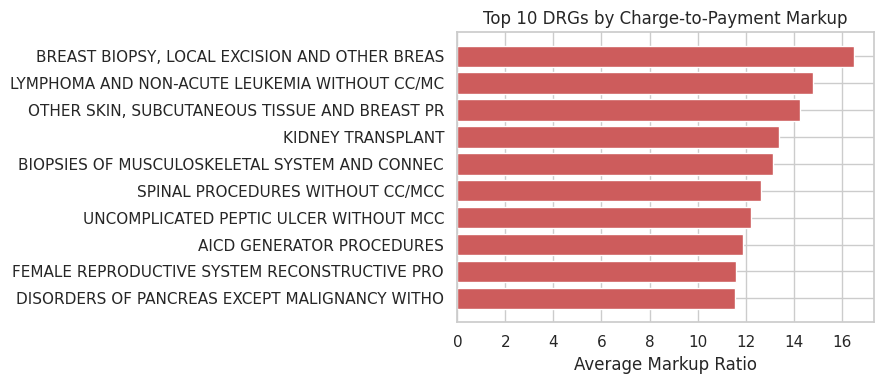

In [ ]:
top10 = drg_gap.head(10).sort_values('avg_markup_ratio')
plt.figure(figsize=(9, 4))
plt.barh(top10.index.str.slice(0, 45), top10['avg_markup_ratio'], color='indianred')
plt.xlabel('Average Markup Ratio')
plt.title('Top 10 DRGs by Charge-to-Payment Markup')
plt.tight_layout()
plt.show()


> **Observation:** The highest-markup DRGs (16.5x for Breast Biopsy/Local Excision procedures, 14.8x for Lymphoma/Non-Acute Leukemia without CC/MCC, 13.4x for Kidney Transplant) are a mix of lower-severity, shorter-stay procedures and high-cost specialty care — suggesting markup is not simply a function of how complex or expensive the underlying procedure is.

**Cross-check: which DRGs actually drive the most total Medicare dollars (volume × cost)?**

In [ ]:
print('Top 10 DRGs by total Medicare $ paid out (volume x cost):')

df.groupby('DRG_Desc').apply(
    lambda g: (g['Avg_Mdcr_Pymt_Amt'] * g['Tot_Dschrgs']).sum()
).sort_values(ascending=False).head(10)


Top 10 DRGs by total Medicare $ paid out (volume x cost):


/tmp/ipykernel_347/978400033.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df.groupby('DRG_Desc').apply(


,0
DRG_Desc,
SEPTICEMIA OR SEVERE SEPSIS WITHOUT MV >96 HOURS WITH MCC,"8,464,294,995.24"
INFECTIOUS AND PARASITIC DISEASES WITH O.R. PROCEDURES WITH MCC,"3,071,100,261.32"
HEART FAILURE AND SHOCK WITH MCC,"3,066,627,765.71"
RESPIRATORY INFECTIONS AND INFLAMMATIONS WITH MCC,"2,300,823,234.95"
ENDOVASCULAR CARDIAC VALVE REPLACEMENT AND SUPPLEMENT PROCEDURES WITHOUT MCC,"1,605,119,694.48"
"ECMO OR TRACHEOSTOMY WITH MV >96 HOURS OR PRINCIPAL DIAGNOSIS EXCEPT FACE, MOUTH AND NEC","1,366,525,651.42"
PERCUTANEOUS AND OTHER INTRACARDIAC PROCEDURES WITHOUT MCC,"1,314,028,961.43"
SEPTICEMIA OR SEVERE SEPSIS WITH MV >96 HOURS,"1,195,637,881.79"
SIMPLE PNEUMONIA AND PLEURISY WITH MCC,"1,180,781,512.29"


> **Observation:** By total dollars paid out, the ranking looks completely different from the markup ranking — **Septicemia/Severe Sepsis without MV >96 Hours with MCC** alone accounts for **$8.46B** in total Medicare payments, more than 2.7x the next DRG. High-markup DRGs (Section 6.1) and high-total-spend DRGs (this cell) are largely *different* diagnoses — the biggest markup multiples occur on relatively low-volume procedures, while the real national spend is concentrated in high-volume, common acute-care conditions.

### 6.2 Geographic variation in the payment gap

In [ ]:
# note this purely related to markup ratio and states regardless of provider or DRG
state_gap = df.groupby('Rndrng_Prvdr_State_Abrvtn').agg(

    avg_submitted_charge=('Avg_Submtd_Cvrd_Chrg', 'mean'),
    avg_medicare_payment=('Avg_Mdcr_Pymt_Amt', 'mean'),
    avg_markup_ratio=('Markup_Ratio', 'mean'),
    total_discharges=('Tot_Dschrgs', 'sum')
).sort_values('avg_markup_ratio', ascending=False)

state_gap.head(10)


,avg_submitted_charge,avg_medicare_payment,avg_markup_ratio,total_discharges
Rndrng_Prvdr_State_Abrvtn,,,,
NV,"157,565.70","14,973.75",11.32,43038
FL,"111,252.88","12,767.14",9.32,442057
CO,"133,423.01","16,084.75",8.86,46512
NJ,"117,613.97","15,453.86",8.73,172663
TX,"114,226.51","14,722.06",8.11,331707
CA,"151,799.54","21,043.96",7.83,441762
AZ,"101,558.89","15,330.13",7.34,93586
AL,"80,929.49","11,669.86",7.25,70206
KS,"89,510.11","13,454.37",7.13,51595


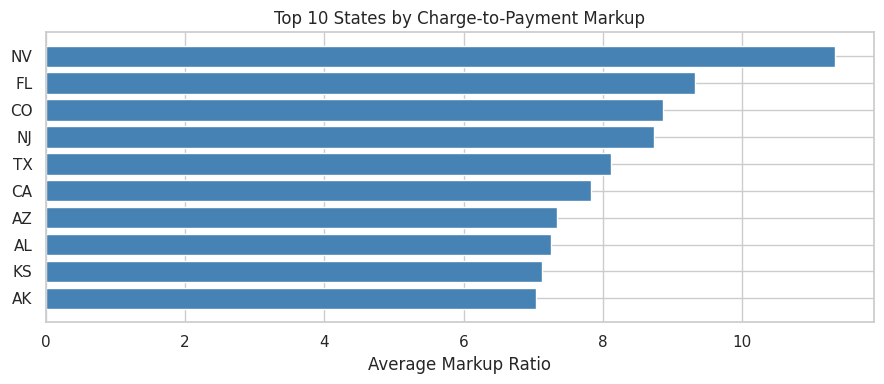

In [ ]:
top10_states = state_gap.head(10).sort_values('avg_markup_ratio')
plt.figure(figsize=(9, 4))
plt.barh(top10_states.index, top10_states['avg_markup_ratio'], color='steelblue')
plt.xlabel('Average Markup Ratio')
plt.title('Top 10 States by Charge-to-Payment Markup')
plt.tight_layout()
plt.show()


> **Observation:** State-level markup ranges from **11.3x in Nevada** and **9.3x in Florida** down to much lower multiples elsewhere, mirroring the same state pattern seen in the peer-outlier and DRG-holding-constant analyses (Sections 2.5 and 3.2) — Nevada, Florida, Colorado, New Jersey and Texas consistently show up as the most aggressive-markup states across every method used in this notebook.

### 6.3 Does rurality affect the payment gap?

In [ ]:
ruca_gap = df.groupby('Rndrng_Prvdr_RUCA_Desc').agg(
    avg_submitted_charge=('Avg_Submtd_Cvrd_Chrg', 'mean'),
    avg_medicare_payment=('Avg_Mdcr_Pymt_Amt', 'mean'),
    avg_markup_ratio=('Markup_Ratio', 'mean'),
    n_records=('DRG_Cd', 'count')
).sort_values('avg_markup_ratio', ascending=False)

ruca_gap.head(5)

,avg_submitted_charge,avg_medicare_payment,avg_markup_ratio,n_records
Rndrng_Prvdr_RUCA_Desc,,,,
"Secondary flow 30% to <50% to a larger urbanized area of 50,000 and greater","74,769.57","11,583.06",6.90,2415
Unknown,"89,520.00","13,859.57",6.74,574
"Metropolitan area high commuting: primary flow 30% or more to a urbanized area of 50,000 and greater","69,338.91","11,564.80",6.63,2243
"Metropolitan area core: primary flow within an urbanized area of 50,000 and greater","96,175.56","15,890.16",6.50,127034
"Micropolitan high commuting: primary flow 30% or more to a urban cluster of 10,000 to 49,999","52,091.91","9,646.08",5.61,595


> **Observation:** Rurality has a comparatively modest effect on markup relative to state and hospital effects — average markup ranges narrowly from about **5.6x to 6.9x** across RUCA categories, versus the ~4–5x spread seen between the highest- and lowest-markup *states* (Section 6.2). Rural/urban setting is a secondary factor; state and individual hospital/system pricing policy matter more.

### 6.4 Which providers/hospitals have the biggest markup?
Restricted to providers with a reasonable volume (≥100 total discharges) so a single low-cost DRG doesn't distort the ranking.

In [ ]:
provider_gap = df.groupby(['Rndrng_Prvdr_Org_Name', 'Rndrng_Prvdr_State_Abrvtn']).agg(
    avg_markup_ratio=('Markup_Ratio', 'mean'),
    total_discharges=('Tot_Dschrgs', 'sum'),
    n_drgs=('DRG_Cd', 'nunique')
).query('total_discharges >= 100').sort_values('avg_markup_ratio', ascending=False)

provider_gap.head(10)

,,avg_markup_ratio,total_discharges,n_drgs
Rndrng_Prvdr_Org_Name,Rndrng_Prvdr_State_Abrvtn,,,
Capital Health Medical Center - Hopewell,NJ,30.79,1296,49
Capital Health Regional Medical Center,NJ,28.71,897,35
Carepoint Health-Christ Hospital,NJ,28.13,255,9
Carepoint Health - Bayonne Medical Center,NJ,23.52,643,25
Gadsden Regional Medical Center,AL,20.43,1080,38
Hca Florida Pasadena Hospital,FL,19.96,585,28
Summerlin Hospital Medical Center,NV,19.85,2363,79
Western Arizona Regional Medical Center,AZ,19.38,773,31
Hca Florida South Shore Hospital,FL,19.23,1384,50


> **Observation:** The highest-markup hospitals nationally — **Capital Health Medical Center (Hopewell, NJ, 30.8x)**, **Capital Health Regional Medical Center (NJ, 28.7x)**, **Carepoint Health-Christ Hospital (NJ, 28.1x)**, **Carepoint Health-Bayonne (NJ, 23.5x)** — are dominated by a small cluster of New Jersey systems, consistent with the system-level pricing pattern flagged earlier (peer-outlier hospitals sharing ownership, Section 2). Florida (HCA-affiliated), Alabama, Nevada and Arizona hospitals round out the rest of the top 10, reinforcing that a small number of states and health systems account for most of the extreme markup behavior across this entire analysis.

## 7. Executive Summary

| Area | Key finding |
|---|---|
| Data quality | 146,142 clean provider–DRG records after removing suppressed/missing rows and a handful of illogical rows (payment > charge). No duplicates. |
| Headline gap | Hospitals bill a **median 5.5x (mean 6.35x)** what Medicare actually pays; the typical dollar gap is **~79% of the submitted charge**. |
| Outlier providers | **201 hospitals** have ≥15% of their DRGs flagged as peer-group cost outliers; several are flagged on 100% of their DRGs. |
| Cost variation by DRG | Some DRGs (e.g., cardiac congenital/valvular disorders, interstitial lung disease) show CV > 1.0 — providers disagree wildly on price for the *same* diagnosis; others are highly consistent (CV ≈ 0.4). |
| Regional variation (fixed DRG) | For the single most common DRG, the highest-billing state charges **6.2x** more than the lowest, while Medicare's payment barely moves (<2x range) — Maryland's uniquely low markup (~1.2x) reflects its state-regulated all-payer rate system. |
| Volume / economies of scale | Higher-volume hospitals bill *more*, not less, per case — no evidence of economies of scale; largely confounded by case-mix breadth (high-volume hospitals treat far more distinct DRGs). |
| Charge–payment relationship | r = 0.81 between charge and Medicare payment — real but far from 1:1. |
| Predictors of cost | DRG identity alone explains 58% of billed-amount variance; once that's controlled for, hospital case-mix breadth and Region are the strongest remaining predictors of pricing behavior (Random Forest R²=0.25). |
| Highest-markup DRGs | Breast biopsy/excision procedures (16.5x), lymphoma without CC/MCC (14.8x), kidney transplant (13.4x) — not simply the most complex/expensive procedures. |
| Highest-spend DRGs | Septicemia/severe sepsis with MCC alone accounts for **$8.46B** in Medicare payments — 2.7x the next DRG — driven by volume, not markup. |
| Geography | Nevada, Florida, Colorado, New Jersey and Texas are consistently the highest-markup states across every method used (peer outliers, fixed-DRG comparison, state aggregation). |
| Rurality | A secondary factor — markup varies narrowly (5.6x–6.9x) by RUCA category, much less than the spread seen between states. |
| Provider concentration | The most extreme hospital-level markups cluster in a small number of New Jersey systems (Capital Health, Carepoint Health) and HCA-affiliated Florida hospitals — a system-level, not random, pattern. |


In [ ]:
Thank you